# DATA-445 In-Class Assignment 2

Consider the `Real_Estate.csv` data file posted on Blackboard (under the In-Class 2 assignment link). This file contains information related to 414 houses. The goal is to predict the house price of unit area.

## 1. (3 points) Using the pandas library, read the csv data file and create a data-frame called `house_price`.

In [7]:
import pandas as pd

house_price = pd.read_csv("Real_Estate.csv")
house_price


,No,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


## 2. (3 points) Drop the `No` column.

In [8]:
house_price = house_price.drop(columns=["No"], axis=1)
house_price.head

<bound method NDFrame.head of      transaction_date  house_age  distance_to_the_nearest_MRT_station  \
0            2012.917       32.0                             84.87882   
1            2012.917       19.5                            306.59470   
2            2013.583       13.3                            561.98450   
3            2013.500       13.3                            561.98450   
4            2012.833        5.0                            390.56840   
..                ...        ...                                  ...   
409          2013.000       13.7                           4082.01500   
410          2012.667        5.6                             90.45606   
411          2013.250       18.8                            390.96960   
412          2013.000        8.1                            104.81010   
413          2013.500        6.5                             90.45606   

     number_of_convenience_stores  latitude  longitude  \
0                              10  

## 3. (4 points) Create a scatter plot of `house_age` and `house_price_of_unit_area`. Describe the plot.

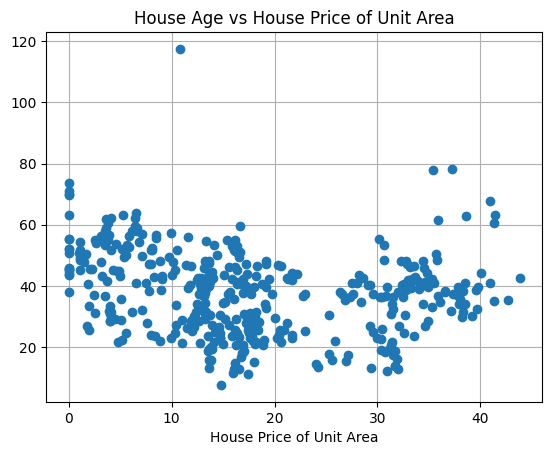

In [13]:
import matplotlib.pyplot as plt

plt.plot(house_price["house_age"], house_price["house_price_of_unit_area"], 'o')
plt.title("House Age vs House Price of Unit Area")
plt.xlabel("House Age")
plt.xlabel("House Price of Unit Area")
plt.grid()
plt.show()

from the above scatterplot we see two groups in the dataset. Newer (less than or eqaul to 25 years old) and older (greater than or equal to 25 years old). The house price unit of unit area of each of those groups behave different (probably beccause of the location and other features associated to the houses)

## 4. (4 points) Create a scatter plot of `distance_to_the_nearest_MRT_station` and `house_price_of_unit_area`. Describe the plot.

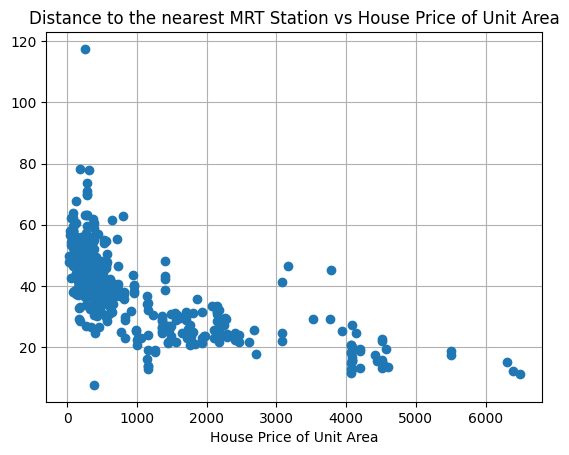

In [14]:
plt.plot(house_price["distance_to_the_nearest_MRT_station"], house_price["house_price_of_unit_area"], 'o')
plt.title("Distance to the nearest MRT Station vs House Price of Unit Area")
plt.xlabel("Distance to the Nearest MRT Station")
plt.xlabel("House Price of Unit Area")
plt.grid()
plt.show()

From the above plot, we can see that the closer the house is to the MRT station on average the higher the price of the house unit area. Also because it is mentioning a train station this may point to a house on the east coast.

## 5. (5 points) Build a linear regression model

Input variables: `house_age`, `distance_to_the_nearest_MRT_station`, `number_of_convenience_stores`, `latitude`, and `longitude`.

Target variable: `house_price_of_unit_area`.

In [16]:
from sklearn.linear_model import LinearRegression

# defining the impots and target variables 
x = house_price[["house_age", "distance_to_the_nearest_MRT_station", 
                 "number_of_convenience_stores", "latitude", "longitude"]]
y = house_price["house_price_of_unit_area"]

#creating the linear regression model 
model = LinearRegression()
model.fit(x,y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 6. (3 points) Using the model from part 5, predict the house price of unit area

For a house with: `house_age = 5`, `distance_to_the_nearest_MRT_station = 500`, `number_of_convenience_stores = 3`, `latitude = 24.98`, and `longitude = 121.49`.

In [17]:
# Defining the imput for prediction

new_data = pd.DataFrame({
    "house_age": [5],
    "distance_to_the_nearest_MRT_station": [500],
    "number_of_convenience_stores": [3],
    "latitude": [24.98],
    "longitude": [121.49]
})
new_data

,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude
0,5,500,3,24.98,121.49


In [18]:
#Predicting the house price of unit area for the new data

predicted_price = model.predict(new_data)
print (f"Predicted House Price of Unit Area: {predicted_price[0]:.2f}")

Predicted House Price of Unit Area: 45.56
